In [1]:
import pandas as pd

# Amazon Cardinality

In [2]:
results_df =  pd.read_csv('C:\\Users\Ronza\Dev\DP-MSD\\amazon\\results\\results_from_server\Amazon_Greedy_Results.csv')

In [3]:
results_df

,alg,k,lambda_param,eps,rep,value,relevance,diversity,queries,time_sec
0,nonpriv,10,0.1,0.2,0,0.206032,0.196940,0.287856,9957,2.8897
1,DPGreedy,10,0.1,0.2,0,0.206032,0.196940,0.287856,9957,2.8772
2,DPSampleOblGreedy,10,0.1,0.2,0,0.198343,0.192999,0.246443,2310,0.8144
3,DPSampleGreedy,10,0.1,0.2,0,0.206289,0.201547,0.248975,4489,1.4842
4,Random,10,0.1,0.2,0,0.031115,0.001637,0.296421,0,0.0009
...,...,...,...,...,...,...,...,...,...,...
1345,nonpriv,60,0.8,0.1,9,0.346614,0.334616,0.349614,58232,16.4967
1346,DPGreedy,60,0.8,0.1,9,0.310757,0.241712,0.328018,58232,16.9433
1347,DPSampleOblGreedy,60,0.8,0.1,9,0.317483,0.293084,0.323583,2328,1.4415
1348,DPSampleGreedy,60,0.8,0.1,9,0.304988,0.210901,0.328510,8079,2.8766


## Impact of k on score

In [4]:
results_df['alg'] = results_df['alg'].replace(
    {
        'nonpriv': 'Greedy',
        'DPGreedy': 'DP-Greedy',
        'DPSampleOblGreedy': 'DP-OSG',
        'DPSampleGreedy': 'DP-NOSG',
        'Random': 'Random'
    }
)

In [5]:
print(results_df.head())    

         alg   k  lambda_param  eps  rep     value  relevance  diversity  \
0     Greedy  10           0.1  0.2    0  0.206032   0.196940   0.287856   
1  DP-Greedy  10           0.1  0.2    0  0.206032   0.196940   0.287856   
2     DP-OSG  10           0.1  0.2    0  0.198343   0.192999   0.246443   
3    DP-NOSG  10           0.1  0.2    0  0.206289   0.201547   0.248975   
4     Random  10           0.1  0.2    0  0.031115   0.001637   0.296421   

   queries  time_sec  
0     9957    2.8897  
1     9957    2.8772  
2     2310    0.8144  
3     4489    1.4842  
4        0    0.0009  


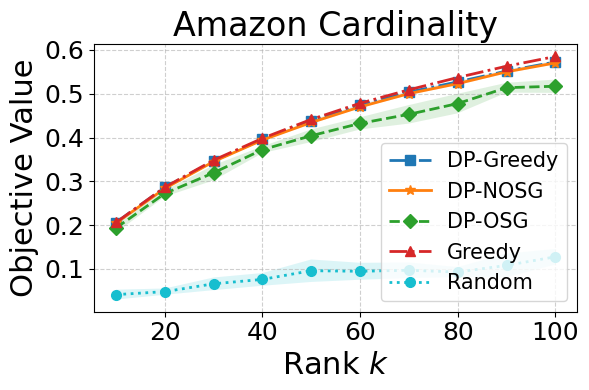

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

plt.xticks(range(20, 110, 20), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=15, frameon=True) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_cardinality_k_on_val.pdf')
plt.show()

## Impact of eps on score

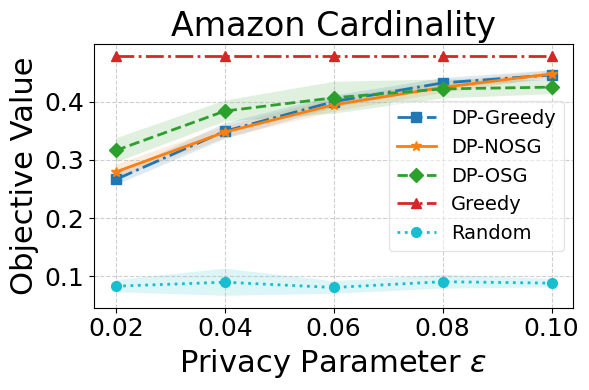

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 60
eps_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
# eps_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'] == 0.1) & 
    (results_df['eps'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'eps'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    line, = plt.plot(
    alg_data['eps'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['eps'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )

# Formatting with exact fontsizes from your reference
plt.xlabel('Privacy Parameter $\\varepsilon$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(eps_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_cardinality_eps_on_val.pdf')
plt.show()

## Impact of k on num queries

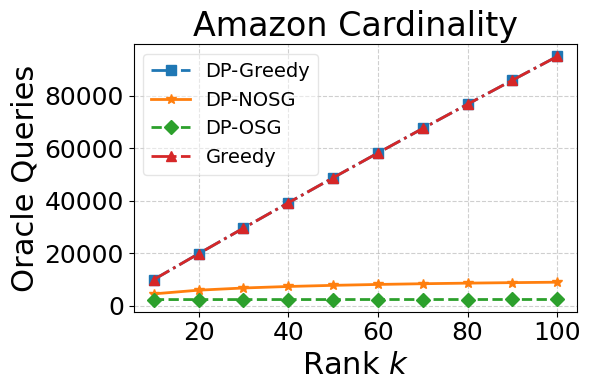

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[
    (results_df['eps'] == 0.2) 
    & (results_df['lambda_param'] == 0.1) 
    & results_df['k'].isin(list(range(10, 110, 10)))
    & ~results_df['alg'].isin(['Random'])
    
]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['queries'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=3,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Oracle Queries', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

plt.xticks(range(20, 110, 20), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_cardinality_k_on_queries.pdf')
plt.show()

## Impact of k on execution time

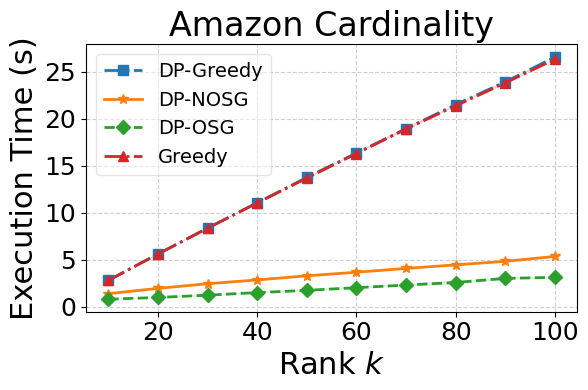

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & ~results_df['alg'].isin(['Random']) & (results_df['lambda_param'] == 0.1) & results_df['k'].isin(list(range(10, 110, 10)))]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['time_sec'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Execution Time (s)', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

plt.xticks(range(20, 110, 20), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_cardinality_k_on_time.pdf')
plt.show()

# Matroid Constraints

## Impact of lambda on score

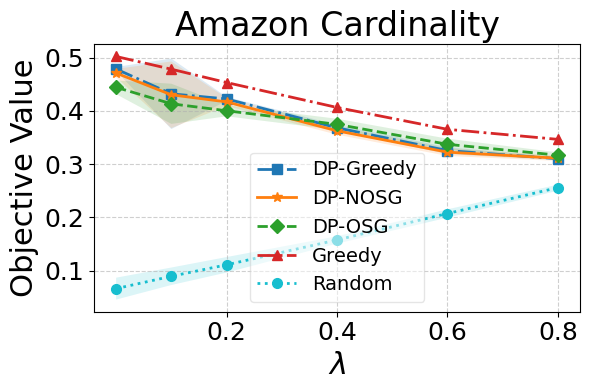

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 60
lambda_list = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

filtered_df = results_df[
    (results_df['k'] == target_k) 
    # (results_df['lambda_param'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'lambda_param'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    line, = plt.plot(
    alg_data['lambda_param'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['lambda_param'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )

# Formatting with exact fontsizes from your reference
plt.xlabel('$\\lambda$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(lambda_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_cardinality_lambda_on_val.pdf')
plt.show()

In [11]:
results_df

,alg,k,lambda_param,eps,rep,value,relevance,diversity,queries,time_sec
0,Greedy,10,0.1,0.2,0,0.206032,0.196940,0.287856,9957,2.8897
1,DP-Greedy,10,0.1,0.2,0,0.206032,0.196940,0.287856,9957,2.8772
2,DP-OSG,10,0.1,0.2,0,0.198343,0.192999,0.246443,2310,0.8144
3,DP-NOSG,10,0.1,0.2,0,0.206289,0.201547,0.248975,4489,1.4842
4,Random,10,0.1,0.2,0,0.031115,0.001637,0.296421,0,0.0009
...,...,...,...,...,...,...,...,...,...,...
1345,Greedy,60,0.8,0.1,9,0.346614,0.334616,0.349614,58232,16.4967
1346,DP-Greedy,60,0.8,0.1,9,0.310757,0.241712,0.328018,58232,16.9433
1347,DP-OSG,60,0.8,0.1,9,0.317483,0.293084,0.323583,2328,1.4415
1348,DP-NOSG,60,0.8,0.1,9,0.304988,0.210901,0.328510,8079,2.8766
